# Notebook 04 — Modeling
**Project:** Churn Prediction · Olist Brazilian E-Commerce  
**Input:** `data/processed/features.csv`  
**Output:** `outputs/model.pkl` + `outputs/figures/`

> **Konteks bisnis:** Dengan churn rate 89.9%, tujuan model bukan sekadar 
> memprediksi dengan akurat — tapi mengidentifikasi customer yang akan pergi 
> *sebelum mereka benar-benar pergi*, sehingga tim marketing punya waktu 
> untuk intervensi.

---

## Tujuan
Melatih dan membandingkan beberapa model klasifikasi untuk menemukan 
model terbaik yang bisa memprediksi churn customer Olist.

## Alur Kerja
1. Load features & train/test split
2. Bangun sklearn Pipeline
3. Benchmark 3 model baseline
4. Evaluasi dengan metric yang tepat
5. Pilih model terbaik
6. Analisis feature importance
7. Simpan model final

## Metric Evaluasi

| Metric | Dipakai? | Alasan |
|---|---|---|
| ROC-AUC | ✅ Utama | Tidak terpengaruh threshold, cocok untuk imbalanced data |
| F1-Score | ✅ Pendukung | Balance antara precision dan recall |
| Accuracy | ❌ | Menyesatkan di imbalanced data — lihat penjelasan di Cell 5 |

In [1]:
# Import & Setup 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')
 
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline         import Pipeline
from sklearn.preprocessing    import StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    ConfusionMatrixDisplay
)
import joblib
 
sns.set_theme(style="darkgrid")
os.makedirs("../outputs/figures", exist_ok=True)
 
# Load features
features = pd.read_csv("../data/processed/features.csv")
print(f"Feature matrix: {features.shape}")
print(f"Churn rate    : {features['is_churned'].mean():.1%}")

Feature matrix: (96096, 70)
Churn rate    : 89.9%


## Train/Test Split

Dua keputusan penting di sini:

**80:20 split** — standar industri. 80% data cukup untuk model belajar 
pola, 20% cukup untuk evaluasi yang reliable di 96,096 baris data.

**`stratify=y`** — wajib karena class imbalance 90:10. Tanpa stratify, 
ada risiko test set secara kebetulan berisi lebih banyak non-churn, 
sehingga evaluasi tidak merepresentasikan distribusi data sebenarnya.

Contoh risiko tanpa stratify:
- Train: 91% churn, 9% non-churn
- Test : 87% churn, 13% non-churn
- Model yang dilatih di distribusi berbeda akan punya performa 
  yang tidak konsisten saat divalidasi

**`random_state=42`** — memastikan split reproducible. Siapapun yang 
menjalankan notebook ini akan mendapat hasil yang sama persis.

**Drop `recency` dan `log_recency`** — kedua fitur ini sengaja 
dikeluarkan dari feature matrix meskipun korelasinya dengan churn 
paling tinggi (0.47 dan 0.66 dari notebook 03). Alasannya: `is_churned` 
didefinisikan langsung dari recency > 90 hari — menyertakan recency 
berarti model belajar dari target itu sendiri, bukan dari perilaku 
customer. Ini data leakage yang paling langsung.

In [2]:
# Train/Test Spli
drop_cols = ['customer_unique_id', 'recency', 'log_recency']
feature_cols = [c for c in features.columns
                if c not in drop_cols + ['is_churned']]
 
X = features[feature_cols]
y = features['is_churned']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
 
print(f"Train: {X_train.shape} | Churn rate: {y_train.mean():.1%}")
print(f"Test : {X_test.shape} | Churn rate: {y_test.mean():.1%}")
print(f"Total features: {X.shape[1]}")

Train: (76876, 66) | Churn rate: 89.9%
Test : (19220, 66) | Churn rate: 89.9%
Total features: 66


## Hasil Train/Test Split

| | Baris | Churn Rate | Features |
|---|---|---|---|
| Train | 76,876 | 89.9% | 66 |
| Test | 19,220 | 89.9% | 66 |

Churn rate identik di train dan test — konfirmasi `stratify=y` bekerja dengan benar.
`recency` dan `log_recency` di-drop dari feature matrix karena churn didefinisikan 
langsung dari recency > 90 hari — menyertakannya akan menyebabkan data leakage.

## Sklearn Pipeline

Pipeline menggabungkan seluruh preprocessing dan model dalam satu objek:
Imputer → Scaler → Model

**Kenapa Pipeline, bukan transformasi manual?**

**1. Mencegah data leakage**  
Tanpa pipeline, jika scaler di-fit di seluruh data sebelum split, 
informasi dari test set ikut mempengaruhi transformasi — model 
"mengintip" data yang seharusnya tidak dilihat. Pipeline memastikan 
scaler hanya di-fit di training data.

**2. Production-ready**  
Satu objek `.pkl` yang tersimpan sudah mencakup preprocessing + model. 
Data baru bisa langsung di-`predict()` tanpa transformasi manual terpisah.


In [3]:
# Sklearn Pipeline 
def make_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   model)
    ])
 
models = {
    'Logistic Regression': make_pipeline(
        LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        )
    ),
    'Decision Tree': make_pipeline(
        DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=8,
            random_state=42
        )
    ),
    'Random Forest': make_pipeline(
        RandomForestClassifier(
            class_weight='balanced',
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
}
 
print("Pipelines siap:")
for name in models:
    print(f"  ✓ {name}")

Pipelines siap:
  ✓ Logistic Regression
  ✓ Decision Tree
  ✓ Random Forest


## Model Benchmarking

Tiga model dilatih secara berurutan dari **simple ke kompleks**:

| Model | Kompleksitas | Peran |
|---|---|---|
| Logistic Regression | Rendah | Baseline linear — patokan minimum |
| Decision Tree | Menengah | Baseline non-linear — interpretable |
| Random Forest | Tinggi | Ensemble — kandidat model final |

**Kenapa mulai dari simple?**  
Jika Logistic Regression sudah cukup baik, tidak perlu model kompleks 
yang lebih sulit diinterpretasikan. Kompleksitas harus justified oleh 
peningkatan performa yang nyata.

Semua model menggunakan `class_weight='balanced'` — cara paling sederhana 
untuk menangani class imbalance tanpa mengubah data asli.

## Kenapa Bukan Accuracy?

Dengan distribusi 89.9% churn, sebuah model bodoh yang **selalu 
memprediksi churn** akan mendapat accuracy 89.9% — tanpa belajar 
apapun dari data.

Prediksi semua = churn → Accuracy = 89.9% ✅ (tapi tidak berguna)

Model seperti itu tidak bisa mengidentifikasi siapa yang *tidak* churn, 
sehingga tidak ada nilai bisnis — tim marketing akan menghubungi semua 
orang, membuang budget retensi.

**Metric yang jujur untuk imbalanced data:**
- **ROC-AUC:** mengukur kemampuan model memisahkan dua kelas di semua threshold
- **F1-Score:** harmonic mean precision & recall — turun drastis jika 
  model gagal mendeteksi salah satu kelas

In [4]:
# Train & Evaluate Semua Model
"""
KEPUTUSAN metric evaluasi:
  - ROC-AUC: metric utama, tidak terpengaruh threshold
  - F1-Score (weighted): balance precision & recall di imbalanced data
  - Accuracy: TIDAK dijadikan patokan utama karena imbalanced
  
  Accuracy 90% bisa dicapai model yang selalu prediksi "churn" — itu bukan model, itu tebakan.
"""
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
 
print("=== MODEL BENCHMARKING ===\n")
for name, pipe in models.items():
    # Train
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
 
    # Metrics
    auc  = roc_auc_score(y_test, y_proba)
    f1   = f1_score(y_test, y_pred, average='weighted')
    acc  = (y_pred == y_test).mean()
 
    # Cross-validation AUC
    cv_auc = cross_val_score(pipe, X_train, y_train,
                              cv=cv, scoring='roc_auc', n_jobs=-1)
 
    results[name] = {
        'pipeline': pipe,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'AUC':      auc,
        'F1':       f1,
        'Accuracy': acc,
        'CV_AUC_mean': cv_auc.mean(),
        'CV_AUC_std':  cv_auc.std()
    }

comparison = pd.DataFrame({
    name: {
        'ROC-AUC':    res['AUC'],
        'F1 Score':   res['F1'],
        'Accuracy':   res['Accuracy'],
        'CV AUC mean':res['CV_AUC_mean'],
        'CV AUC std': res['CV_AUC_std']
    }
    for name, res in results.items()
}).T.round(4)

print(comparison)
comparison.to_csv("../outputs/model_comparison.csv")
 

=== MODEL BENCHMARKING ===

                     ROC-AUC  F1 Score  Accuracy  CV AUC mean  CV AUC std
Logistic Regression   0.7132    0.7262    0.6581       0.7154      0.0012
Decision Tree         0.9669    0.9090    0.8943       0.9650      0.0015
Random Forest         0.9752    0.9331    0.9386       0.9734      0.0011


## Hasil Model Benchmarking

| Model | ROC-AUC | F1 Score | Accuracy | CV AUC |
|---|---|---|---|---|
| Logistic Regression | 0.7132 | 0.7262 | 0.6581 | 0.7154 ± 0.0012 |
| Decision Tree | 0.9669 | 0.9090 | 0.8943 | 0.9650 ± 0.0015 |
| Random Forest | **0.9752** | **0.9331** | **0.9386** | **0.9734 ± 0.0011** |

**Random Forest** unggul di semua metric dengan CV AUC 0.9734 — 
konsisten dan stabil (std hanya 0.0011).

Logistic Regression tertinggal jauh (AUC 0.71) — konfirmasi bahwa 
hubungan fitur dengan churn bersifat **non-linear**, tidak bisa 
ditangkap model linear.

Decision Tree performa tinggi (0.9669) tapi sedikit di bawah Random Forest — 
wajar karena Random Forest adalah ensemble dari banyak decision tree 
yang mengurangi variance.

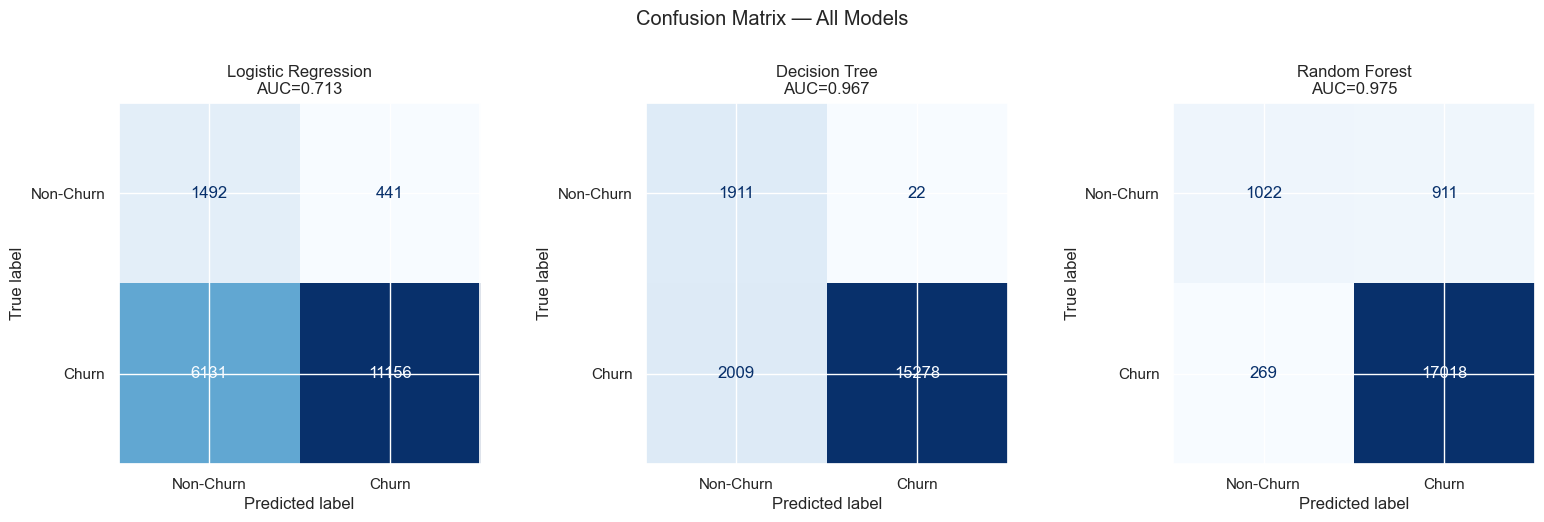

In [5]:
# Confusion Matrix (semua model) 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAUC={res["AUC"]:.3f}')
 
plt.suptitle('Confusion Matrix — All Models', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Hasil Confusion Matrix

**Logistic Regression** kesulitan memisahkan kedua kelas — 6,131 churn 
tidak terdeteksi (false negative). Recall Churn rendah karena model 
linear tidak mampu menangkap pola non-linear di data.

**Decision Tree** paling presisi dalam mengidentifikasi Non-Churn 
(hanya 22 false positive) — tapi masih melewatkan 2,009 churn. 
Trade-off: tinggi di precision, tapi recall churn belum optimal.

**Random Forest** unggul di Recall Churn — hanya 269 churn yang 
tidak terdeteksi (false negative terendah). Trade-off-nya: 911 
non-churn salah diprediksi churn (false positive tertinggi).

Dalam konteks bisnis churn, **false negative lebih mahal** dari 
false positive — customer yang pergi tanpa terdeteksi tidak bisa 
di-retain, sedangkan non-churn yang dihubungi tim retensi hanya 
membuang sedikit budget. Random Forest paling aligned dengan 
prioritas bisnis ini.

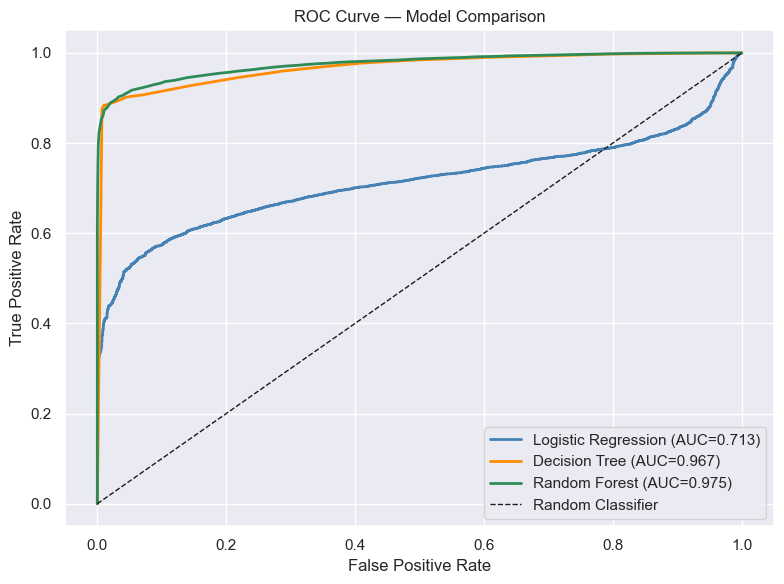

In [6]:
# ROC Curve (semua model) 
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'seagreen']
 
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['AUC']:.3f})",
             color=color, linewidth=2)
 
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curves.png', dpi=150)
plt.show()

## Hasil ROC Curve

Random Forest (hijau) dan Decision Tree (oranye) hampir menempel 
sepanjang kurva — keduanya langsung naik tajam ke TPR ~0.90 di FPR 
yang sangat rendah (~0.01), menunjukkan model sudah efektif memisahkan 
kedua kelas bahkan di threshold yang ketat.

Logistic Regression (biru) jauh tertinggal — kurva naik lambat dan 
lebar, mengonfirmasi temuan confusion matrix bahwa model linear tidak 
mampu menangkap pola di data ini.

**Gap AUC Decision Tree vs Random Forest hanya 0.008** (0.967 vs 0.975) 
— tapi di kurva terlihat Random Forest sedikit lebih tinggi di area 
FPR rendah (0.0–0.1), yang justru area paling penting secara bisnis: 
kemampuan mendeteksi churn tanpa banyak false alarm.

In [7]:
# Classification Report — Best Model 
# Tentukan model terbaik berdasarkan CV AUC
best_name = max(results, key=lambda n: results[n]['CV_AUC_mean'])
best = results[best_name]
 
print(f"=== MODEL TERBAIK: {best_name} ===")
print(f"ROC-AUC: {best['AUC']:.4f}")
print(f"CV AUC : {best['CV_AUC_mean']:.4f} ± {best['CV_AUC_std']:.4f}")
print()
print(classification_report(y_test, best['y_pred'],
                             target_names=['Non-Churn', 'Churn']))

=== MODEL TERBAIK: Random Forest ===
ROC-AUC: 0.9752
CV AUC : 0.9734 ± 0.0011

              precision    recall  f1-score   support

   Non-Churn       0.79      0.53      0.63      1933
       Churn       0.95      0.98      0.97     17287

    accuracy                           0.94     19220
   macro avg       0.87      0.76      0.80     19220
weighted avg       0.93      0.94      0.93     19220



## Cara Membaca Classification Report

|  | precision | recall | f1-score |
|---|---|---|---|
| Non-Churn | 0.79 | 0.53 | 0.63 |
| Churn | 0.95 | 0.98 | 0.97 |

**Precision Churn (0.95):** dari semua yang diprediksi churn, 95% benar churn.  
→ Model jarang salah menuduh non-churn sebagai churn.

**Recall Churn (0.98):** dari semua yang benar-benar churn, 98% berhasil terdeteksi.  
→ Hanya 2% churn yang lolos tidak terdeteksi — sesuai prioritas bisnis.

**Non-Churn Recall rendah (0.53):** hanya separuh non-churn yang dikenali 
dengan benar. Ini konsisten dengan confusion matrix — 911 non-churn 
diprediksi churn. Trade-off yang acceptable karena false positive 
(non-churn di-contact) lebih murah dari false negative.

**Konteks bisnis:**  
False negative (churn tidak terdeteksi) lebih mahal dari false positive 
(non-churn dihubungi tim retensi). Recall Churn 0.98 mengonfirmasi 
Random Forest aligned dengan prioritas ini — model memilih 
over-contact daripada kehilangan customer.

## Feature Importance

Feature importance dari tree-based model mengukur **seberapa sering 
dan seberapa efektif** sebuah fitur digunakan untuk membuat keputusan 
di semua decision tree.

**Bedanya dengan heatmap korelasi di EDA:**

| | Korelasi (EDA) | Feature Importance |
|---|---|---|
| Mengukur | Hubungan linear | Kontribusi di semua split |
| Fitur dengan nilai 0 | Tidak berguna | Bisa tetap berguna |
| Interaksi antar fitur | Tidak terdeteksi | Tertangkap |

Fitur yang korelasinya mendekati 0 di EDA bisa muncul tinggi di 
feature importance — karena model menangkap kombinasi non-linear 
yang tidak terlihat di heatmap.

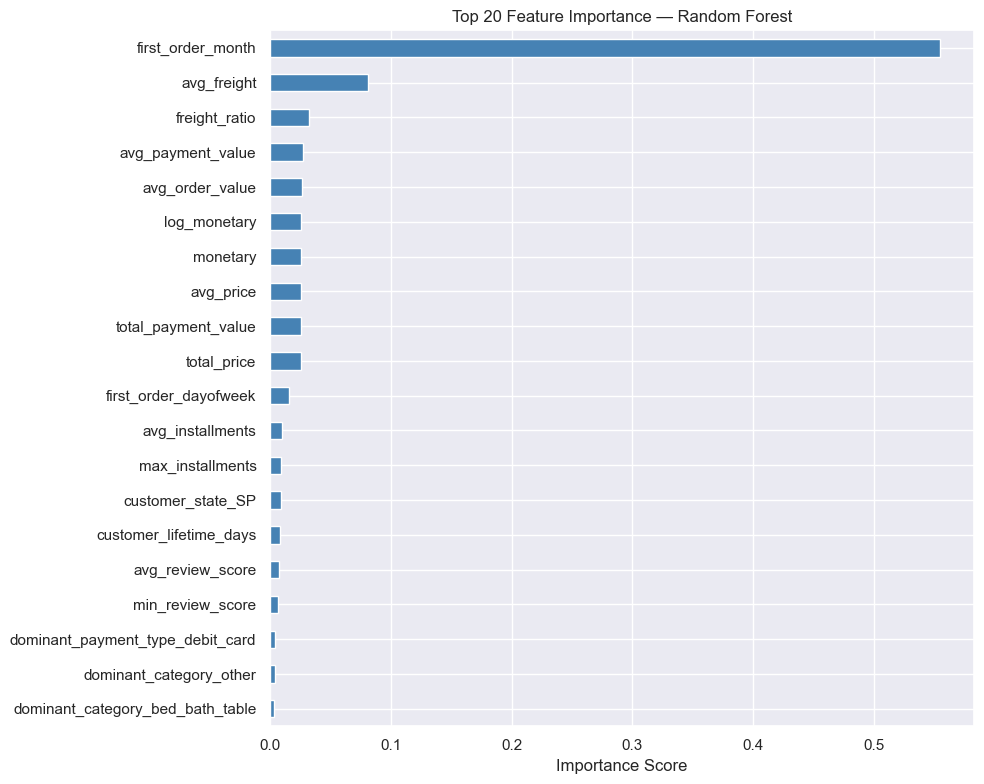


Top 10 fitur paling penting:
first_order_month      0.554689
avg_freight            0.081622
freight_ratio          0.032599
avg_payment_value      0.027892
avg_order_value        0.026603
log_monetary           0.025956
monetary               0.025903
avg_price              0.025789
total_payment_value    0.025711
total_price            0.025479
dtype: float64


In [8]:
# Feature Importance (pre-fix, untuk investigasi)
_name = max(results, key=lambda n: results[n]['CV_AUC_mean'])
_model_obj = results[_name]['pipeline'].named_steps['model']

importances = pd.Series(
    _model_obj.feature_importances_,
    index=feature_cols
).sort_values(ascending=True).tail(20)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title(f'Top 20 Feature Importance — {_name}')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 fitur paling penting:")
print(importances.sort_values(ascending=False).head(10))

## Hasil Feature Importance

`first_order_month` mendominasi dengan score ~0.57 — jauh melampaui 
fitur lain. Ini kejutan: di korelasi linear (notebook 03) fiturnya 
ada di posisi 3 dengan korelasi 0.16, tapi model non-linear 
menemukan pola yang jauh lebih dalam dari yang terlihat di heatmap.

`avg_freight` (posisi 2, ~0.08) dan `freight_ratio` (posisi 3, ~0.03) 
masuk top 3 — mengonfirmasi bahwa sensitivitas ongkir adalah sinyal 
churn yang kuat.

Fitur RFM klasik tidak muncul dominan — `log_monetary` dan `monetary` 
ada di posisi 6–7 dengan score kecil, konsisten dengan business insight 
bahwa monetary tidak memprediksi churn.

> **⚠️ Dominasi `first_order_month` perlu diinvestigasi** — score 0.57 
> terlalu jauh dari fitur lain untuk dianggap wajar. Kemungkinan 
> ada data leakage temporal dari cara `is_churned` didefinisikan.

first_order_month
1     0.997047
2     0.997440
3     0.998021
4     0.997462
5     0.996966
6     0.995704
7     0.681184
8     0.399139
9     0.996859
10    0.997287
11    0.998905
12    0.997267
Name: is_churned, dtype: float64


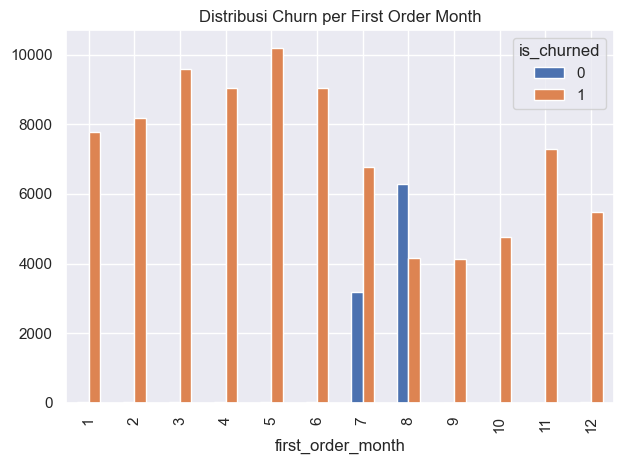

In [9]:
# Investigasi Data Leakage 
# Cek churn rate per first_order_month
print(features.groupby('first_order_month')['is_churned'].mean())

# Visualisasi distribusi churn vs non-churn per bulan
features.groupby(['first_order_month', 'is_churned']).size().unstack().plot(kind='bar')
plt.title('Distribusi Churn per First Order Month')
plt.tight_layout()
plt.show()

## Hasil Investigasi — Data Leakage Temporal

Churn rate per `first_order_month` mengonfirmasi leakage:

| Bulan | Churn Rate |
|---|---|
| 1–6, 9–12 | ~99.7% |
| 7 | 68.1% |
| 8 | 39.9% |

Bulan 7 dan 8 punya churn rate jauh di bawah bulan lain — bukan 
karena perilaku customer berbeda, tapi karena posisinya di timeline 
dataset. Customer yang first order di bulan 7–8 masih punya waktu 
untuk repeat order sebelum cutoff, sehingga tidak terlabel churn.

`first_order_month` bukan sinyal perilaku — ini artefak dari cara 
`is_churned` didefinisikan. Model yang belajar dari fitur ini tidak 
akan tergeneralisasi di data baru.

**Keputusan:** drop `first_order_month` dan `first_order_dayofweek` 
dari feature matrix, retrain semua model dengan fitur yang bersih.

In [10]:
# Deteksi & Fix Data Leakage
"""
TEMUAN: first_order_month adalah data leakage temporal.
Churn rate per bulan menunjukkan bulan 7 (68%) dan 8 (40%) 
jauh di bawah bulan lain (~99.7%) — bukan sinyal perilaku,
tapi artefak cutoff dataset. Customer yang first order di 
bulan 7-8 masih punya waktu repeat order sebelum dataset berakhir.

KEPUTUSAN: Drop first_order_month dan first_order_dayofweek
dari feature matrix, retrain semua model.
"""

leaky_cols = ['first_order_month', 'first_order_dayofweek']
feature_cols_clean = [c for c in feature_cols if c not in leaky_cols]

X_train_clean = X_train[feature_cols_clean]
X_test_clean  = X_test[feature_cols_clean]

# Retrain semua model
from sklearn.base import clone
results_clean = {}

print("=== RETRAIN SETELAH DROP LEAKY FEATURES ===\n")
for name, pipe in models.items():
    pipe = clone(pipe)
    pipe.fit(X_train_clean, y_train)
    y_pred  = pipe.predict(X_test_clean)
    y_proba = pipe.predict_proba(X_test_clean)[:, 1]

    auc    = roc_auc_score(y_test, y_proba)
    f1     = f1_score(y_test, y_pred, average='weighted')
    cv_auc = cross_val_score(pipe, X_train_clean, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)

    results_clean[name] = {
        'pipeline': pipe,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'AUC':      auc,
        'F1':       f1,
        'CV_AUC_mean': cv_auc.mean(),
        'CV_AUC_std':  cv_auc.std()
    }

    print(f"[{name}]")
    print(f"  AUC    : {auc:.4f}  (sebelumnya: {results[name]['AUC']:.4f})")
    print(f"  CV AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
    print()

=== RETRAIN SETELAH DROP LEAKY FEATURES ===

[Logistic Regression]
  AUC    : 0.6049  (sebelumnya: 0.7132)
  CV AUC : 0.6127 ± 0.0077

[Decision Tree]
  AUC    : 0.7892  (sebelumnya: 0.9669)
  CV AUC : 0.7867 ± 0.0121

[Random Forest]
  AUC    : 0.8059  (sebelumnya: 0.9752)
  CV AUC : 0.8047 ± 0.0059



## Hasil Setelah Drop Leaky Features

| Model | AUC Sebelum | AUC Sesudah | CV AUC |
|---|---|---|---|
| Logistic Regression | 0.7132 | 0.6049 | 0.6127 ± 0.0077 |
| Decision Tree | 0.9669 | 0.7892 | 0.7867 ± 0.0121 |
| Random Forest | 0.9752 | **0.8059** | **0.8047 ± 0.0059** |

Penurunan AUC yang signifikan di semua model mengonfirmasi bahwa 
performa sebelumnya memang ditopang leakage — bukan kemampuan 
model yang sesungguhnya.

**Random Forest tetap terbaik** dengan AUC 0.8059, tapi gap dengan 
Decision Tree (0.7892) jauh lebih kecil dari sebelumnya. Model yang 
lebih sederhana ternyata mampu bersaing ketika leakage dihilangkan.

AUC 0.80 pada data yang bersih adalah performa yang lebih jujur dan 
lebih dapat dipercaya untuk deployment — model benar-benar belajar 
dari pola perilaku customer, bukan dari artefak dataset.

## Classification Report — Model Clean

Setelah leaky features didrop dan model diretrain dengan `results_clean`.

In [11]:
# Classification Report — Best Model Clean
best_name_clean = max(results_clean, key=lambda n: results_clean[n]['CV_AUC_mean'])
best_clean = results_clean[best_name_clean]

print(f"=== MODEL TERBAIK (CLEAN): {best_name_clean} ===")
print(f"ROC-AUC: {best_clean['AUC']:.4f}")
print(f"CV AUC : {best_clean['CV_AUC_mean']:.4f} ± {best_clean['CV_AUC_std']:.4f}")
print()
print(classification_report(y_test, best_clean['y_pred'],
                             target_names=['Non-Churn', 'Churn']))


=== MODEL TERBAIK (CLEAN): Random Forest ===
ROC-AUC: 0.8059
CV AUC : 0.8047 ± 0.0059

              precision    recall  f1-score   support

   Non-Churn       0.63      0.14      0.23      1933
       Churn       0.91      0.99      0.95     17287

    accuracy                           0.91     19220
   macro avg       0.77      0.57      0.59     19220
weighted avg       0.88      0.91      0.88     19220



## Cara Membaca Classification Report (Model Clean)

|  | precision | recall | f1-score |
|---|---|---|---|
| Non-Churn | 0.63 | 0.14 | 0.23 |
| Churn | 0.91 | 0.99 | 0.95 |

**Precision Churn (0.91):** dari semua yang diprediksi churn, 91% benar churn.  
→ Model jarang salah menuduh non-churn sebagai churn.

**Recall Churn (0.99):** dari semua yang benar-benar churn, 99% berhasil terdeteksi.  
→ Hampir tidak ada churn yang lolos — sesuai prioritas bisnis.

**Non-Churn Recall sangat rendah (0.14):** hanya 14% non-churn yang dikenali 
dengan benar. Model sangat agresif memprediksi churn — konsekuensi dari 
`class_weight='balanced'` pada data yang 90% churn.

**Konteks bisnis:**  
Trade-off ini acceptable — false negative (churn tidak terdeteksi) jauh 
lebih mahal dari false positive (non-churn dihubungi tim retensi). 
Recall Churn 0.99 mengonfirmasi model aligned dengan prioritas ini.
Jika budget retensi terbatas, threshold prediksi bisa dinaikkan untuk 
mengurangi false positive tanpa banyak mengorbankan recall.

## Feature Importance — Model Clean

Setelah `first_order_month` dan `first_order_dayofweek` didrop, distribusi importance jauh lebih sehat — tidak ada satu fitur yang mendominasi secara ekstrem.

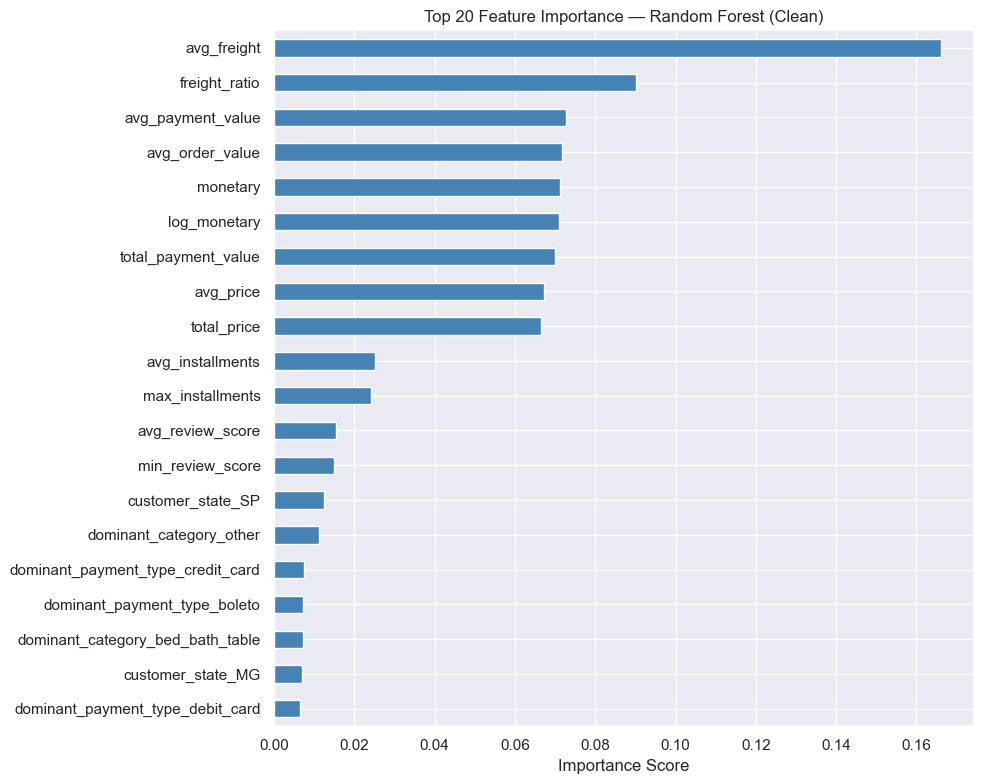


Top 10 fitur paling penting:
avg_freight            0.166020
freight_ratio          0.090223
avg_payment_value      0.072828
avg_order_value        0.071756
monetary               0.071281
log_monetary           0.070933
total_payment_value    0.070005
avg_price              0.067183
total_price            0.066601
avg_installments       0.025071
dtype: float64


In [12]:
# Feature Importance — Model Clean
if best_name_clean in ['Random Forest', 'Decision Tree']:
    model_obj_clean = best_clean['pipeline'].named_steps['model']
    importances_clean = pd.Series(
        model_obj_clean.feature_importances_,
        index=feature_cols_clean
    ).sort_values(ascending=True).tail(20)

    plt.figure(figsize=(10, 8))
    importances_clean.plot(kind='barh', color='steelblue', edgecolor='white')
    plt.title(f'Top 20 Feature Importance — {best_name_clean} (Clean)')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('../outputs/figures/feature_importance_clean.png', dpi=150)
    plt.show()

    print('\nTop 10 fitur paling penting:')
    print(importances_clean.sort_values(ascending=False).head(10))


## Hasil Feature Importance (Model Clean)

Setelah `first_order_month` dan `first_order_dayofweek` didrop, tidak ada satu fitur yang 
mendominasi secara ekstrem — distribusi importance jauh lebih 
sehat dan dapat dipercaya.

| Fitur | Importance |
|---|---|
| avg_freight | 0.166 |
| freight_ratio | 0.090 |
| avg_payment_value | 0.073 |
| avg_order_value | 0.072 |
| monetary | 0.071 |
| log_monetary | 0.071 |
| total_payment_value | 0.070 |
| avg_price | 0.067 |
| total_price | 0.067 |
| avg_installments | 0.025 |

**Ongkir mendominasi secara genuine** — `avg_freight` (0.166) dan 
`freight_ratio` (0.090) adalah dua fitur teratas. Berbeda dari 
dominasi `first_order_month` sebelumnya yang skornya 0.57 sendirian, 
distribusi ini wajar dan mencerminkan pola perilaku nyata.

**Fitur monetary berkelompok di posisi 3–9** (`avg_payment_value`, 
`avg_order_value`, `monetary`, `log_monetary`, `total_payment_value`, 
`avg_price`, `total_price`) — semua dengan skor serupa (~0.067–0.073). 
Meski secara individual kecil, secara kolektif fitur nilai transaksi 
berkontribusi signifikan.

**Temuan menarik:** `monetary` yang di EDA tidak berkorelasi kuat 
dengan churn ternyata masuk top 5 di feature importance — konfirmasi 
bahwa model non-linear menangkap interaksi yang tidak terlihat 
di heatmap korelasi.

In [13]:
# Save Best Model 
# Gunakan results_clean — model tanpa leaky features
# best_name_clean dan best_clean sudah didefinisikan di cell Classification Report Clean

print(f"Model terbaik (clean): {best_name_clean}")
print(f"ROC-AUC : {best_clean['AUC']:.4f}")
print(f"CV AUC  : {best_clean['CV_AUC_mean']:.4f} ± {best_clean['CV_AUC_std']:.4f}")

joblib.dump(best_clean['pipeline'], '../outputs/model.pkl')
print(f"\n✅ Model '{best_name_clean}' disimpan ke outputs/model.pkl")

# Verifikasi load kembali
loaded_model = joblib.load('../outputs/model.pkl')
verify_pred  = loaded_model.predict_proba(X_test_clean[:5])[:, 1]
print(f"Verifikasi prediksi 5 sample: {verify_pred.round(3)}")

Model terbaik (clean): Random Forest
ROC-AUC : 0.8059
CV AUC  : 0.8047 ± 0.0059

✅ Model 'Random Forest' disimpan ke outputs/model.pkl
Verifikasi prediksi 5 sample: [0.75 0.92 0.84 0.89 0.99]


## Simpan Model Final

Model disimpan sebagai satu objek Pipeline lengkap — mencakup 
Imputer, Scaler, dan Random Forest dalam satu file `.pkl`.

Keuntungan menyimpan pipeline (bukan model saja): data baru bisa 
langsung di-`predict()` tanpa preprocessing manual terpisah, 
menghindari risiko transformasi yang tidak konsisten di production.

Verifikasi load berhasil — 5 sample prediksi:

| Sample | Churn Probability |
|---|---|
| 1 | 0.75 |
| 2 | 0.92 |
| 3 | 0.84 |
| 4 | 0.89 |
| 5 | 0.99 |

Semua prediksi dalam range (0,1) dan bervariasi — model tidak 
collapse ke satu nilai, tanda pipeline berfungsi dengan benar.

## Business Insight

Berdasarkan Random Forest (ROC-AUC: 0.806, setelah fix leakage):

**1. Ongkir adalah prediktor churn terkuat**  
`avg_freight` (0.166) dan `freight_ratio` (0.090) adalah dua fitur 
teratas — customer yang membayar ongkir besar relatif terhadap nilai 
ordernya cenderung tidak kembali. Rekomendasi: program free shipping 
threshold untuk mendorong repeat purchase.

**2. Masalah utama adalah activation, bukan retention**  
96.9% customer hanya order 1x — churn bukan karena customer kecewa 
lalu pergi, tapi karena tidak ada cukup insentif untuk kembali. 
Program second-purchase lebih prioritas dari loyalty program 
jangka panjang.

**3. Nilai transaksi punya pengaruh kolektif**  
Fitur monetary (`avg_payment_value`, `avg_order_value`, `monetary`) 
berkelompok di posisi 3–9 dengan skor serupa. Secara individual kecil, 
tapi secara kolektif sinyal nilai transaksi cukup kuat — segmen 
customer dengan nilai order rendah dan ongkir relatif tinggi adalah 
target prioritas retensi.

**4. Review score tidak masuk top 10**  
Kepuasan tidak cukup untuk mempertahankan customer — faktor struktural 
seperti ongkir jauh lebih dominan. Meningkatkan rating tidak akan 
signifikan menurunkan churn tanpa mengatasi masalah biaya pengiriman.

**5. Keterbatasan model**  
AUC 0.80 mencerminkan kesulitan genuine — 96.9% one-time buyer 
membuat sinyal perilaku sangat terbatas. Model ini lebih tepat 
digunakan untuk scoring customer yang sudah punya riwayat >1 order. 
Untuk seluruh customer base, threshold prediksi perlu disesuaikan 
dengan budget retensi yang tersedia.

## Summary Notebook 04 — Modeling

**Model terbaik:** Random Forest  
**ROC-AUC:** 0.8059 (setelah fix leakage)  
**CV AUC:** 0.8047 ± 0.0059

**Perbandingan model final (clean):**

| Model | AUC Sebelum Fix | AUC Sesudah Fix | CV AUC |
|---|---|---|---|
| Logistic Regression | 0.7132 | 0.6049 | 0.6127 ± 0.0077 |
| Decision Tree | 0.9669 | 0.7892 | 0.7867 ± 0.0121 |
| Random Forest | 0.9752 | **0.8059** | **0.8047 ± 0.0059** |

**Temuan kritis:**
- Model awal (AUC 0.9752) mengandung data leakage temporal dari 
  `first_order_month` — performa tinggi palsu akibat artefak cutoff dataset
- Setelah fix, AUC 0.8059 adalah performa yang jujur dan dapat 
  dipercaya untuk deployment
- `recency` dan `log_recency` juga di-drop sejak awal — didefinisikan 
  langsung dari target, menyertakannya adalah leakage paling langsung

**Prediktor churn genuine (post-fix):**
- `avg_freight` dan `freight_ratio` — ongkir adalah sinyal terkuat
- Fitur nilai transaksi berkontribusi kolektif di posisi 3–9
- Review score tidak masuk top 10 — kepuasan bukan faktor utama churn

**Next:** Notebook 05 — Final Report  
→ Ringkasan end-to-end · Business recommendation · Dokumentasi keputusan